In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../data/db/bluestock_mf.db")

In [3]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", engine)

,name
0,01_fund_master
1,02_nav_history
2,03_aum_by_fund_house
3,04_monthly_sip_inflows
4,05_category_inflows
5,06_industry_folio_count
6,07_scheme_performance
7,08_investor_transactions
8,09_portfolio_holdings
9,10_benchmark_indices


In [4]:
performance = pd.read_sql(
    'SELECT * FROM "07_scheme_performance"',
    engine
)

In [5]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [6]:
performance.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     str    
 2   fund_house          40 non-null     str    
 3   category            40 non-null     str    
 4   plan                40 non-null     str    
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_ratio_pct   4

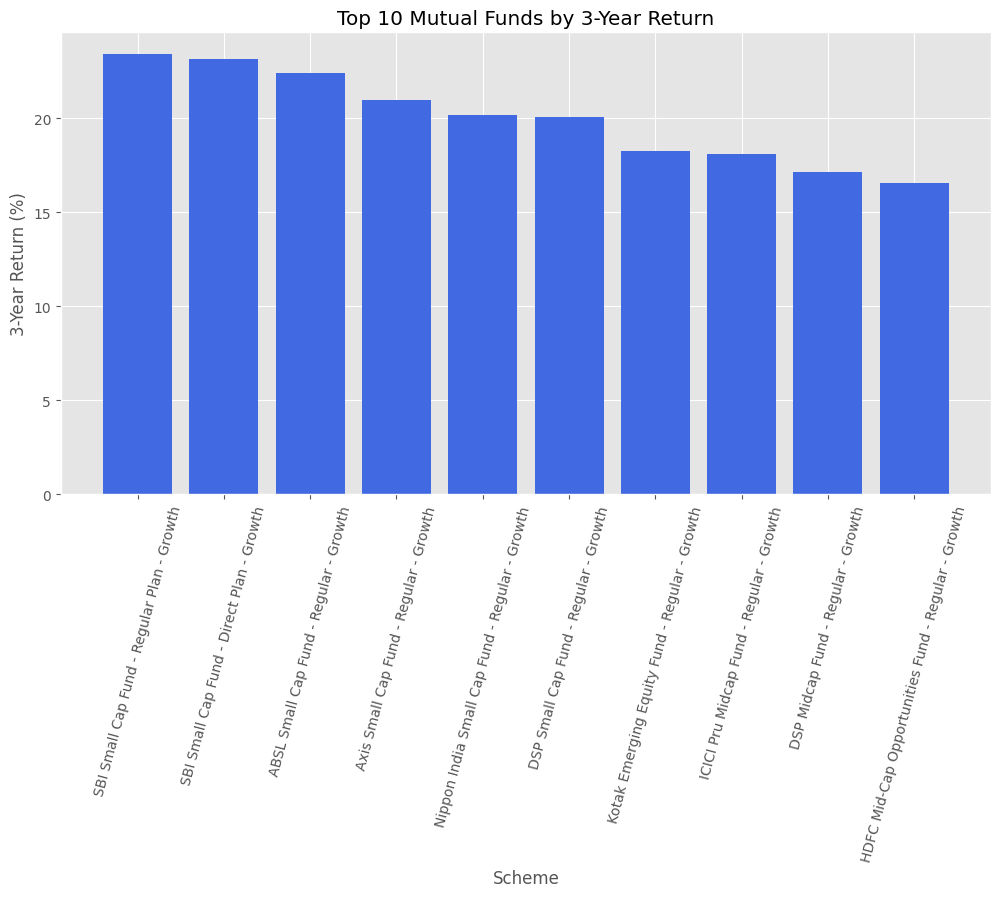

In [7]:
plt.figure(figsize=(12,6))

top10 = performance.sort_values(
    by="return_3yr_pct",
    ascending=False
).head(10)

plt.bar(top10["scheme_name"], top10["return_3yr_pct"], color="royalblue")

plt.title("Top 10 Mutual Funds by 3-Year Return")
plt.xlabel("Scheme")
plt.ylabel("3-Year Return (%)")
plt.xticks(rotation=75)

plt.show()

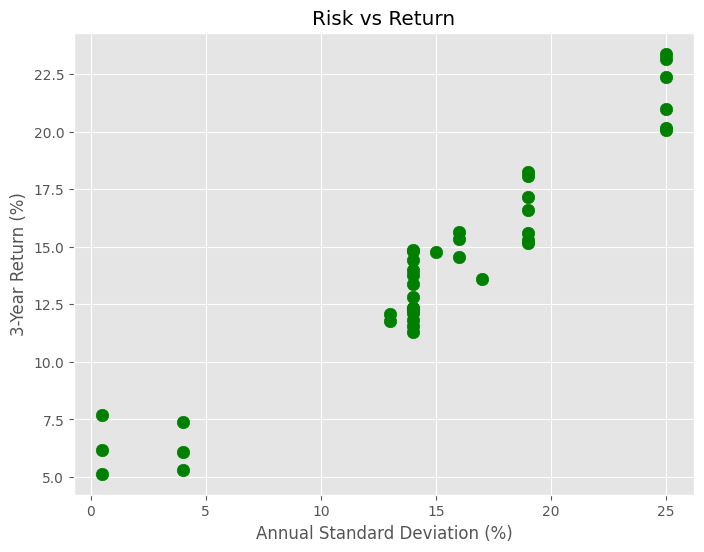

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    performance["std_dev_ann_pct"],
    performance["return_3yr_pct"],
    color="green",
    s=80
)

plt.title("Risk vs Return")
plt.xlabel("Annual Standard Deviation (%)")
plt.ylabel("3-Year Return (%)")

plt.show()

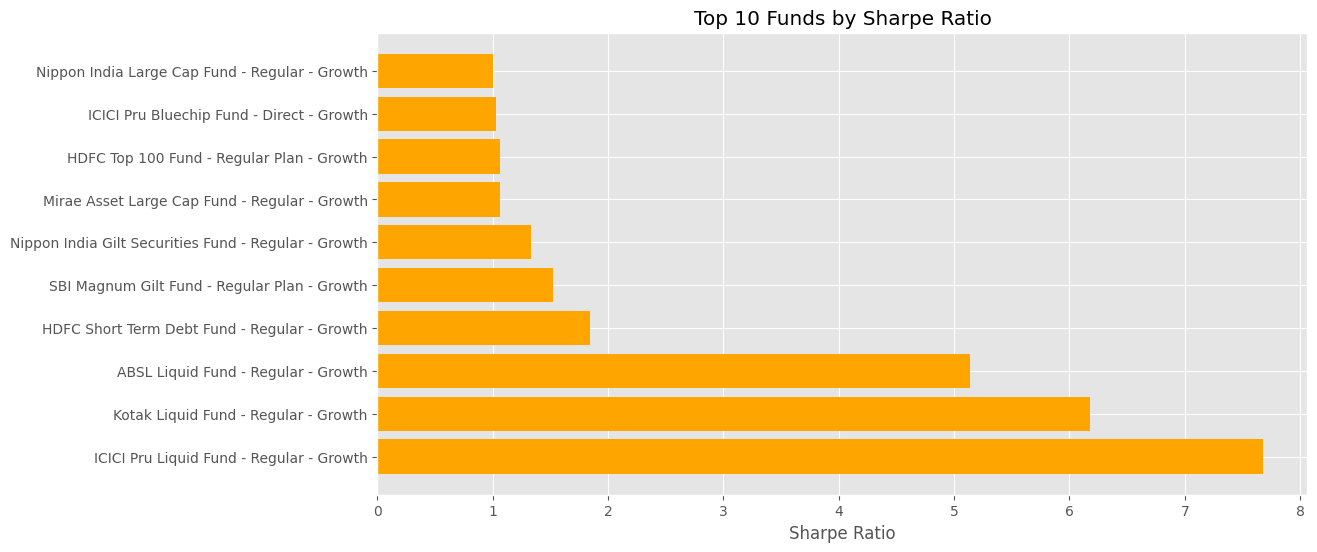

In [9]:
plt.figure(figsize=(12,6))

top_sharpe = performance.sort_values(
    by="sharpe_ratio",
    ascending=False
).head(10)

plt.barh(
    top_sharpe["scheme_name"],
    top_sharpe["sharpe_ratio"],
    color="orange"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")

plt.show()

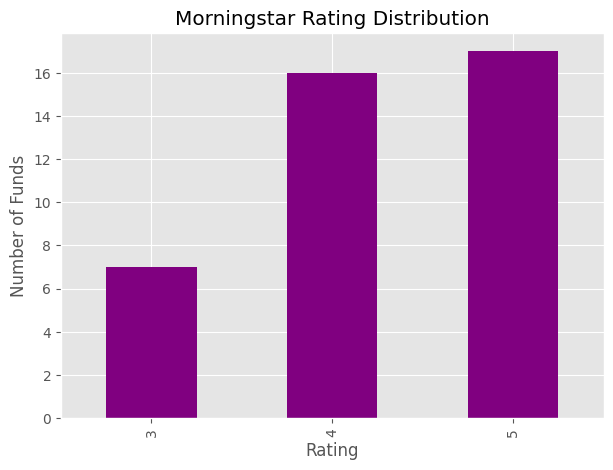

In [10]:
plt.figure(figsize=(7,5))

performance["morningstar_rating"].value_counts().sort_index().plot(
    kind="bar",
    color="purple"
)

plt.title("Morningstar Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Funds")

plt.show()

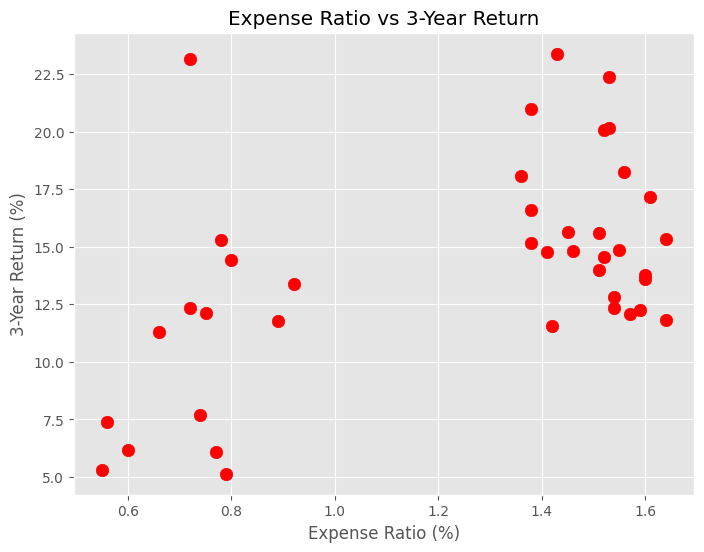

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    performance["expense_ratio_pct"],
    performance["return_3yr_pct"],
    color="red",
    s=80
)

plt.title("Expense Ratio vs 3-Year Return")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("3-Year Return (%)")

plt.show()